In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

In [2]:
q30_malaria = pd.read_csv(f"{BASE_PATH}/phase3_outputs/q30_wash_malaria.csv")
q30_tb = pd.read_csv(f"{BASE_PATH}/phase3_outputs/q30_wash_tb.csv")

for name, df in [("malaria", q30_malaria), ("tb", q30_tb)]:
    print(f"--- {name} ---")
    print("shape:", df.shape, "| countries:", df["country"].nunique(),
          "| years:", df["year"].min(), "-", df["year"].max())
    print(df.isna().sum())
    print()

--- malaria ---
shape: (1900, 5) | countries: 108 | years: 2000 - 2017
country           0
year              0
water_pct         0
sanitation_pct    0
malaria_inc       0
dtype: int64

--- tb ---
shape: (3426, 5) | countries: 195 | years: 2000 - 2017
country           0
year              0
water_pct         0
sanitation_pct    0
tb_inc            0
dtype: int64



In [3]:
# Consistent with prior convention: period averages over the full window,
# since coverage is consistent within each joined file.
malaria_avg = q30_malaria.groupby("country")[["water_pct", "sanitation_pct", "malaria_inc"]].mean().reset_index()
tb_avg = q30_tb.groupby("country")[["water_pct", "sanitation_pct", "tb_inc"]].mean().reset_index()

print("Malaria countries:", len(malaria_avg))
print("TB countries:", len(tb_avg))
malaria_avg.describe()

Malaria countries: 108
TB countries: 195


,water_pct,sanitation_pct,malaria_inc
count,108.000000,108.000000,108.000000
mean,64.025374,54.198104,109.534439
std,22.928073,29.753621,151.498362
min,19.291111,5.363333,0.000000
25%,44.746944,26.811389,1.505156
50%,65.666193,52.881944,16.419951
75%,84.078889,81.064722,204.598611
max,99.015625,100.000000,510.838889


In [4]:
from scipy.stats import spearmanr

combos = [
    ("water_pct", "malaria_inc", malaria_avg),
    ("sanitation_pct", "malaria_inc", malaria_avg),
    ("water_pct", "tb_inc", tb_avg),
    ("sanitation_pct", "tb_inc", tb_avg),
]

for wash_col, disease_col, df in combos:
    rho, p = spearmanr(df[wash_col], df[disease_col])
    print(f"{wash_col} vs {disease_col}: rho={rho:.3f}, p={p:.4f}, n={len(df)}")

water_pct vs malaria_inc: rho=-0.710, p=0.0000, n=108
sanitation_pct vs malaria_inc: rho=-0.813, p=0.0000, n=108
water_pct vs tb_inc: rho=-0.764, p=0.0000, n=195
sanitation_pct vs tb_inc: rho=-0.756, p=0.0000, n=195


In [5]:
def bin_summary(df, wash_col, disease_col, n_bins=10):
    bins = pd.cut(df[wash_col], bins=range(0, 101, n_bins), include_lowest=True)
    summary = df.groupby(bins)[disease_col].agg(
        median="median", q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75), n="count"
    )
    return summary

water_malaria_bins = bin_summary(malaria_avg, "water_pct", "malaria_inc")
san_malaria_bins = bin_summary(malaria_avg, "sanitation_pct", "malaria_inc")
water_tb_bins = bin_summary(tb_avg, "water_pct", "tb_inc")
san_tb_bins = bin_summary(tb_avg, "sanitation_pct", "tb_inc")

water_malaria_bins

,median,q25,q75,n
water_pct,,,,
"(10.0, 20.0]",418.994444,418.994444,418.994444,1
"(20.0, 30.0]",201.438889,85.533333,271.073611,10
"(30.0, 40.0]",285.597222,170.151944,380.986111,12
"(40.0, 50.0]",158.179444,40.562778,233.588889,9
"(50.0, 60.0]",104.322778,33.912222,386.605556,17
"(60.0, 70.0]",5.715556,2.718333,85.588194,10
"(70.0, 80.0]",2.262778,0.079503,12.060833,11
"(80.0, 90.0]",2.347222,0.527078,9.095833,22
"(90.0, 100.0]",1.028729,0.222875,3.467403,16


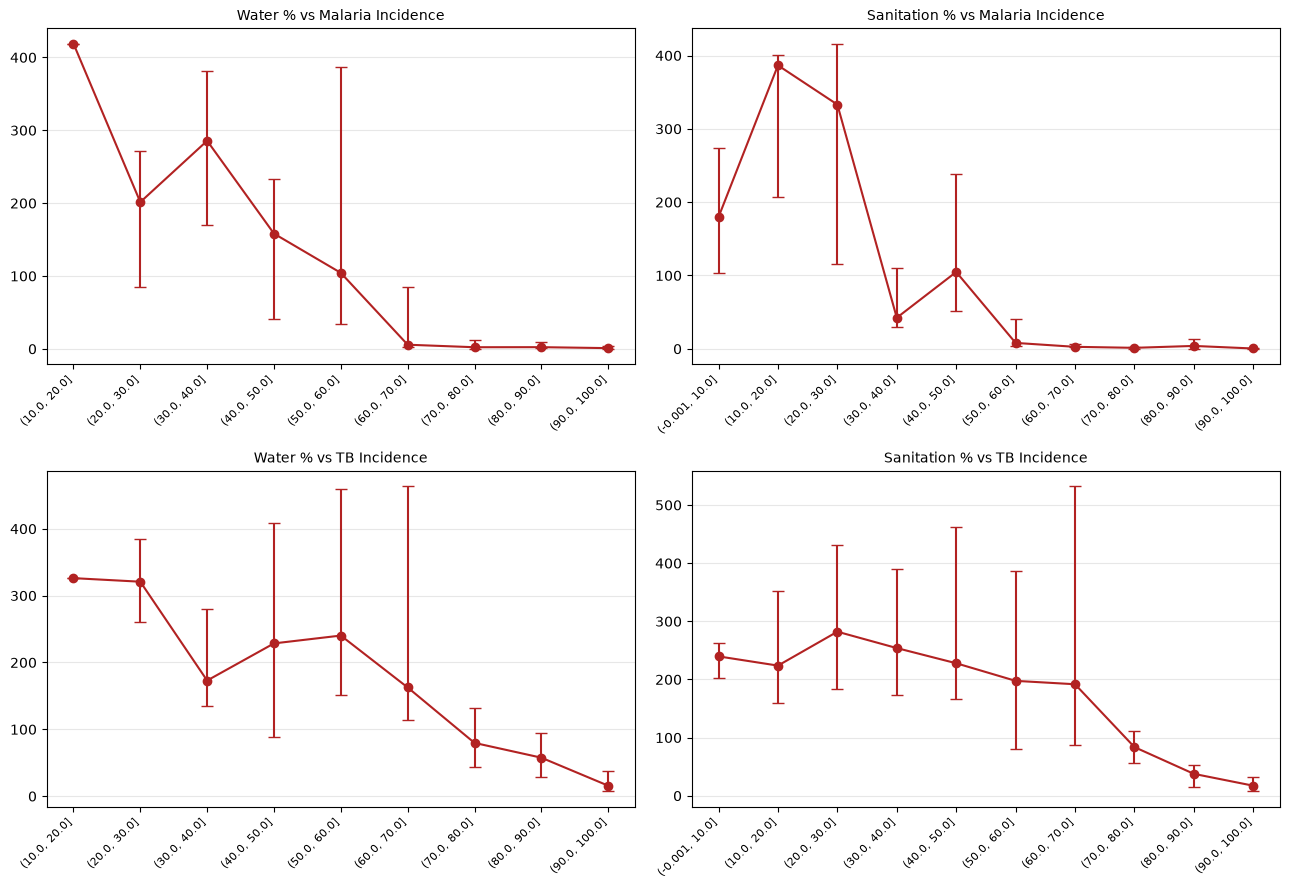

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_specs = [
    (water_malaria_bins, "Water % vs Malaria Incidence", axes[0, 0]),
    (san_malaria_bins, "Sanitation % vs Malaria Incidence", axes[0, 1]),
    (water_tb_bins, "Water % vs TB Incidence", axes[1, 0]),
    (san_tb_bins, "Sanitation % vs TB Incidence", axes[1, 1]),
]

for summary, title, ax in plot_specs:
    x = np.arange(len(summary))
    medians = summary["median"]
    lower_err = medians - summary["q25"]
    upper_err = summary["q75"] - medians
    ax.errorbar(x, medians, yerr=[lower_err, upper_err], fmt="o-", color="firebrick", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in summary.index], rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import mannwhitneyu

def find_threshold(df, wash_col, disease_col, candidates=range(10, 100, 10), min_group=10):
    results = []
    for t in candidates:
        below = df[df[wash_col] <= t][disease_col]
        above = df[df[wash_col] > t][disease_col]
        if len(below) < min_group or len(above) < min_group:
            continue
        u_stat, p_val = mannwhitneyu(below, above, alternative="two-sided")
        results.append({
            "threshold": t, "n_below": len(below), "n_above": len(above),
            "median_below": below.median(), "median_above": above.median(),
            "p_value": p_val
        })
    return pd.DataFrame(results).sort_values("p_value")

threshold_water_malaria = find_threshold(malaria_avg, "water_pct", "malaria_inc")
threshold_san_malaria = find_threshold(malaria_avg, "sanitation_pct", "malaria_inc")
threshold_water_tb = find_threshold(tb_avg, "water_pct", "tb_inc")
threshold_san_tb = find_threshold(tb_avg, "sanitation_pct", "tb_inc")

threshold_water_malaria

,threshold,n_below,n_above,median_below,median_above,p_value
3,60,49,59,202.316667,2.572444,1.596631e-12
4,70,59,49,158.179444,2.242222,1.088389e-11
5,80,70,38,104.518889,1.891944,5.696043e-09
2,50,32,76,222.516667,4.339833,2.128272e-08
1,40,23,85,242.288889,4.875222,2.633832e-07
6,90,92,16,40.334167,1.028729,1.127216e-04
0,30,11,97,211.444444,8.060000,1.881770e-03


In [8]:
summary_rows = []
for name, res in [
    ("Water → Malaria", threshold_water_malaria),
    ("Sanitation → Malaria", threshold_san_malaria),
    ("Water → TB", threshold_water_tb),
    ("Sanitation → TB", threshold_san_tb),
]:
    best = res.iloc[0]
    summary_rows.append({
        "combination": name, "best_threshold": best["threshold"],
        "median_below": best["median_below"], "median_above": best["median_above"],
        "p_value": best["p_value"]
    })

threshold_summary = pd.DataFrame(summary_rows)
threshold_summary

,combination,best_threshold,median_below,median_above,p_value
0,Water → Malaria,60.0,202.316667,2.572444,1.596631e-12
1,Sanitation → Malaria,50.0,211.444444,1.649444,5.743669e-15
2,Water → TB,80.0,207.777778,21.777778,8.785269e-21
3,Sanitation → TB,80.0,222.416667,19.777778,8.425423e-26


In [9]:
def quadrant_analysis(df, disease_col):
    water_med = df["water_pct"].median()
    san_med = df["sanitation_pct"].median()
    df = df.copy()
    df["water_level"] = np.where(df["water_pct"] >= water_med, "High water", "Low water")
    df["san_level"] = np.where(df["sanitation_pct"] >= san_med, "High sanitation", "Low sanitation")
    return df.groupby(["water_level", "san_level"])[disease_col].agg(["median", "count"])

print("--- Malaria quadrants ---")
print(quadrant_analysis(malaria_avg, "malaria_inc"))
print("\n--- TB quadrants ---")
print(quadrant_analysis(tb_avg, "tb_inc"))

--- Malaria quadrants ---
                                 median  count
water_level san_level                         
High water  High sanitation    0.970333     44
            Low sanitation    21.967500     10
Low water   High sanitation    4.743056     10
            Low sanitation   240.423016     44

--- TB quadrants ---
                                 median  count
water_level san_level                         
High water  High sanitation   17.080556     88
            Low sanitation   108.253268     10
Low water   High sanitation   52.500000     10
            Low sanitation   196.555556     87
